# Bank Marketing Campaign Analysis & Deposit Subscription Prediction

###  Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

c:\Users\pc\AppData\Local\Programs\Python\Python39\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### Load the Dataset


In [2]:
df = pd.read_csv('bank.csv')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### data understanding

In [3]:
df.shape

(11162, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [7]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [11]:
for column in df.columns:
    print(f"unique values in {column} : {df[column].unique().tolist()}")

unique values in age : [59, 56, 41, 55, 54, 42, 60, 37, 28, 38, 30, 29, 46, 31, 35, 32, 49, 43, 26, 40, 33, 23, 48, 45, 36, 52, 53, 39, 57, 51, 44, 24, 50, 27, 34, 47, 25, 58, 61, 68, 75, 22, 69, 66, 85, 72, 90, 67, 71, 21, 74, 65, 62, 83, 70, 76, 77, 19, 73, 63, 20, 78, 95, 64, 79, 82, 18, 86, 84, 87, 92, 81, 80, 93, 88, 89]
unique values in job : ['admin.', 'technician', 'services', 'management', 'retired', 'blue-collar', 'unemployed', 'entrepreneur', 'housemaid', 'unknown', 'self-employed', 'student']
unique values in marital : ['married', 'single', 'divorced']
unique values in education : ['secondary', 'tertiary', 'primary', 'unknown']
unique values in default : ['no', 'yes']
unique values in balance : [2343, 45, 1270, 2476, 184, 0, 830, 545, 1, 5090, 100, 309, 199, 460, 703, 3837, 611, -8, 55, 168, 785, 2067, 388, -192, 381, 40, 22, 3, 307, 759, -1, 65, 82, 10, 390, 311, 414, 5, 119, 4, 1262, 1949, -395, 1165, 2240, 300, 3285, 3923, 1443, 24, 1618, 517, 1521, 2823, 1405, 1535, 159

In [12]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: job
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

Column: marital
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

Column: education
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

Column: default
default
no     10994
yes      168
Name: count, dtype: int64

Column: housing
housing
no     5881
yes    5281
Name: count, dtype: int64

Column: loan
loan
no     9702
yes    1460
Name: count, dtype: int64

Column: contact
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

Column: month
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     3

# Step 4: Data Cleaning

### Observation

After inspecting the dataset during the Data Understanding phase, the following observations were made:

- No missing values were found.
- No duplicate records were detected.
- All columns have appropriate data types.
- The value "unknown" was retained as a valid category because it represents unavailable customer information rather than missing data.

### Conclusion

No data cleaning operations (such as removing duplicates or handling missing values) were required


### EDA 1 : target variable anaylsis

Text(0, 0.5, 'Number of customers')

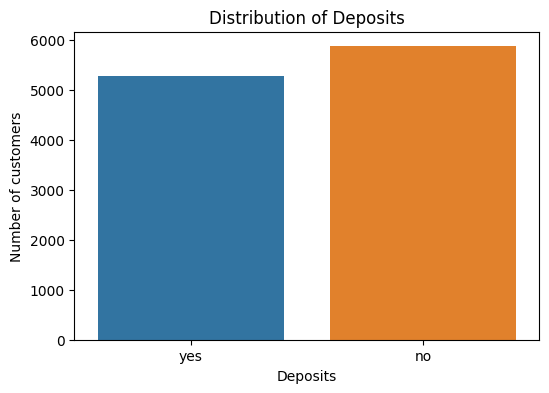

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='deposit')

plt.title('Distribution of Deposits')
plt.xlabel('Deposits')
plt.ylabel('Number of customers')

In [18]:
df["deposit"].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [19]:
(df["deposit"].value_counts(normalize=True) * 100).round(2)

deposit
no     52.62
yes    47.38
Name: proportion, dtype: float64

### EDA 2: Analyze Numerical Feature (Age)


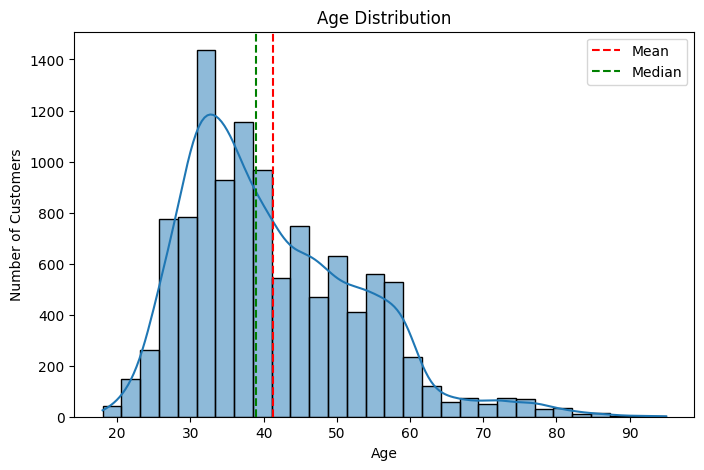

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30, kde=True)

plt.axvline(df["age"].mean(), color="red", linestyle="--", label="Mean")
plt.axvline(df["age"].median(), color="green", linestyle="--", label="Median")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()


In [21]:
df["age"].describe()

count    11162.000000
mean        41.231948
std         11.913369
min         18.000000
25%         32.000000
50%         39.000000
75%         49.000000
max         95.000000
Name: age, dtype: float64

### EDA 3: Account Balance Distribution

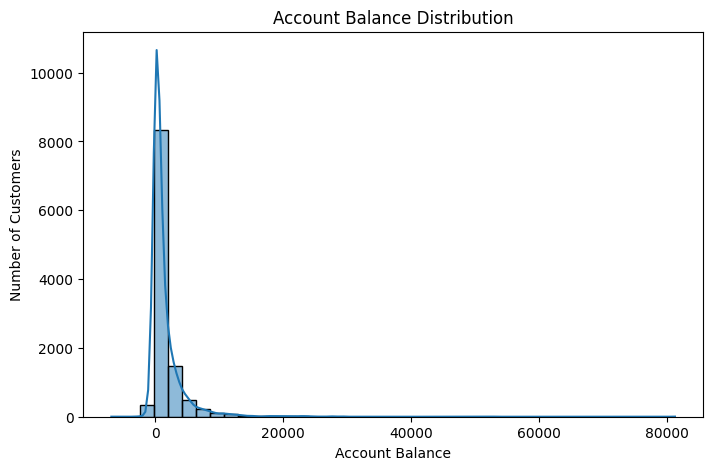

In [23]:

plt.figure(figsize=(8,5))

sns.histplot(df["balance"], bins=40, kde=True)

plt.title("Account Balance Distribution")
plt.xlabel("Account Balance")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
df["balance"].describe()

count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

### EDA 4: Duration Distribution

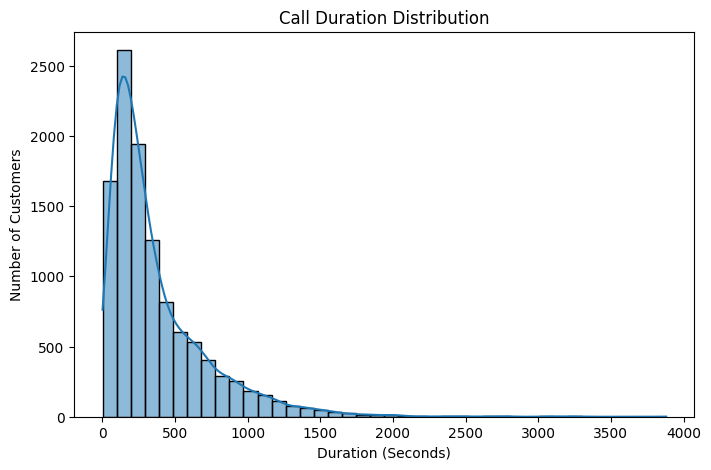

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["duration"], bins=40, kde=True)

plt.title("Call Duration Distribution")
plt.xlabel("Duration (Seconds)")
plt.ylabel("Number of Customers")

plt.show()


In [26]:
df["duration"].describe()

count    11162.000000
mean       371.993818
std        347.128386
min          2.000000
25%        138.000000
50%        255.000000
75%        496.000000
max       3881.000000
Name: duration, dtype: float64

### EDA 5: Campaign Distribution

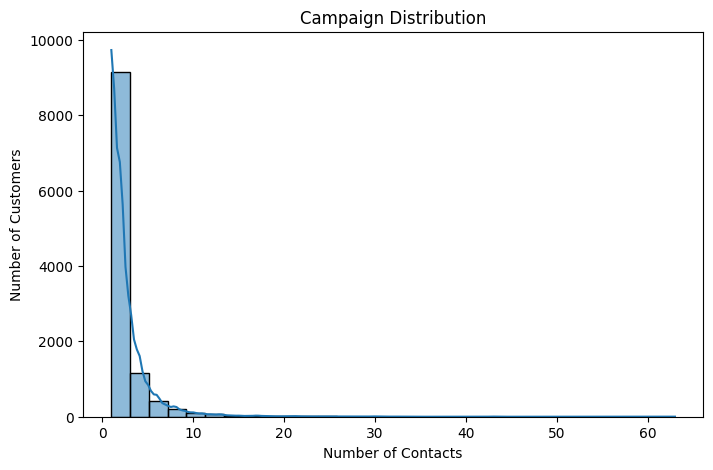

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["campaign"], bins=30, kde=True)

plt.title("Campaign Distribution")
plt.xlabel("Number of Contacts")
plt.ylabel("Number of Customers")

plt.show()



In [28]:
df["campaign"].describe()

count    11162.000000
mean         2.508421
std          2.722077
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64

### EDA 6: Previous Contacts Distribution

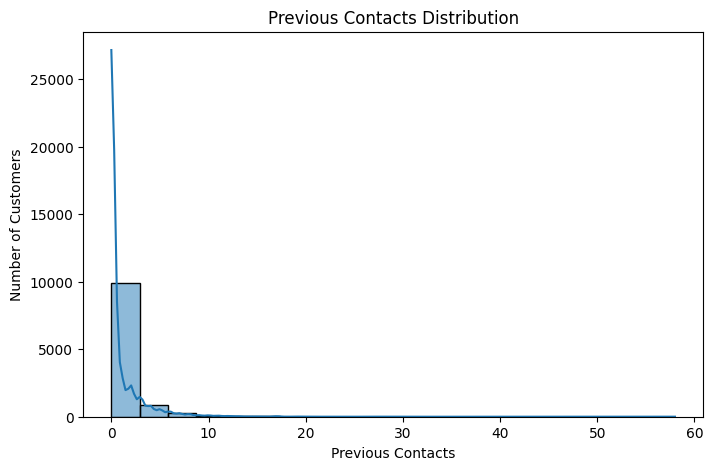

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["previous"], bins=20, kde=True)

plt.title("Previous Contacts Distribution")
plt.xlabel("Previous Contacts")
plt.ylabel("Number of Customers")

plt.show()


In [30]:
df["previous"].describe()

count    11162.000000
mean         0.832557
std          2.292007
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         58.000000
Name: previous, dtype: float64

### EDA 7: Pdays Distribution

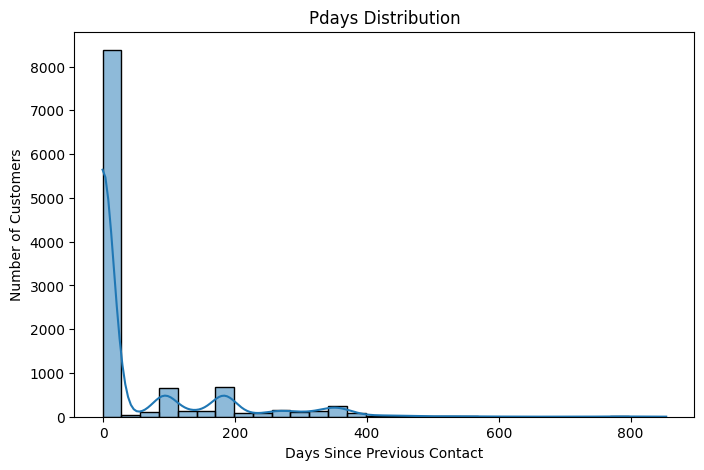

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df["pdays"], bins=30, kde=True)

plt.title("Pdays Distribution")
plt.xlabel("Days Since Previous Contact")
plt.ylabel("Number of Customers")

plt.show()


In [32]:
df["pdays"].describe()

count    11162.000000
mean        51.330407
std        108.758282
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.750000
max        854.000000
Name: pdays, dtype: float64

### EDA 8: Categorical Distribution

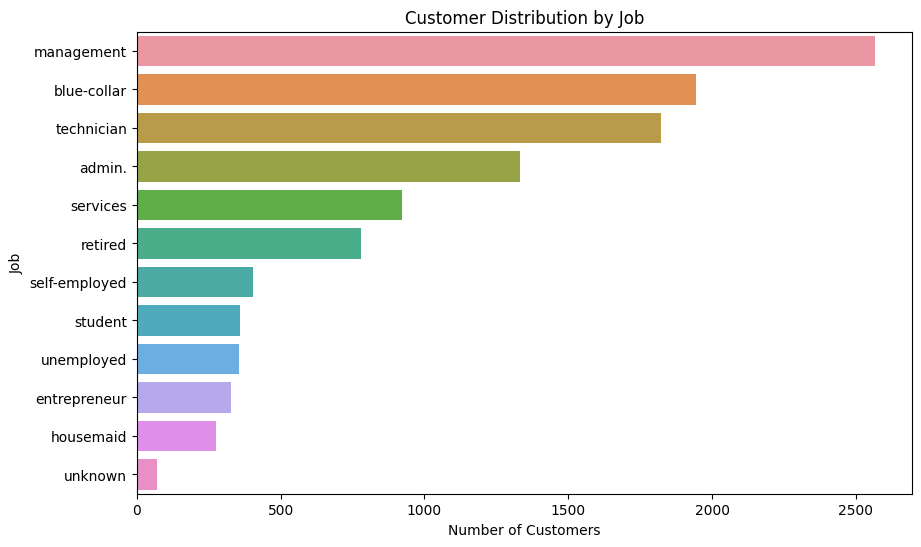

In [33]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y='job',
    order=df['job'].value_counts().index
    )
plt.title("Customer Distribution by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")

plt.show()

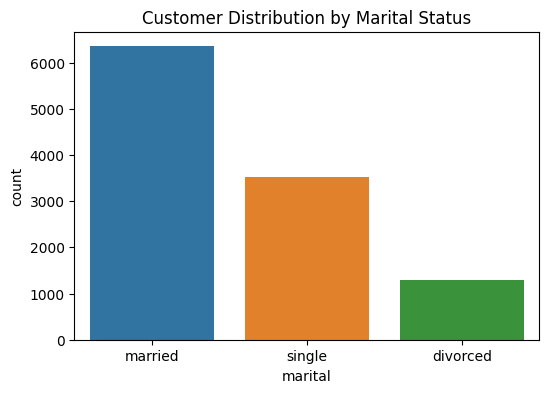

In [34]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="marital")

plt.title("Customer Distribution by Marital Status")

plt.show()

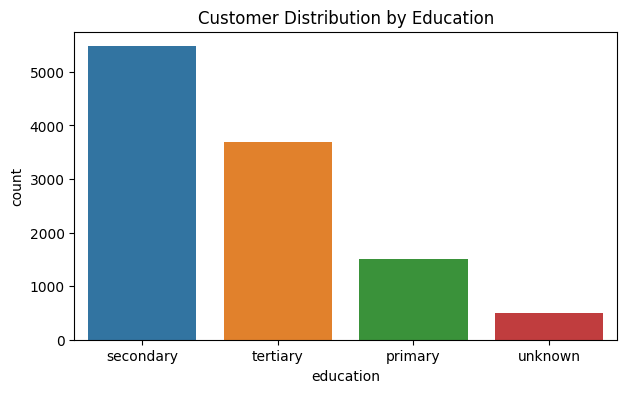

In [35]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="education",
    order=df["education"].value_counts().index
)

plt.title("Customer Distribution by Education")

plt.show()

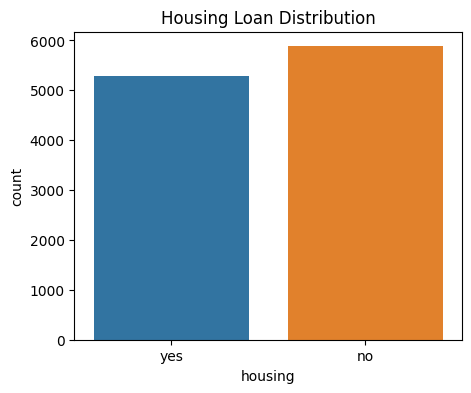

In [36]:
plt.figure(figsize=(5,4))

sns.countplot(data=df, x="housing")

plt.title("Housing Loan Distribution")

plt.show()

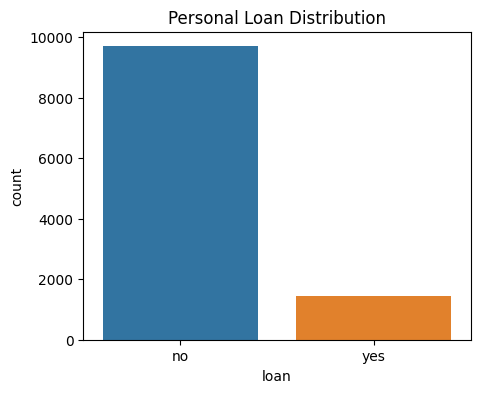

In [37]:
plt.figure(figsize=(5,4))

sns.countplot(data=df, x="loan")

plt.title("Personal Loan Distribution")

plt.show()

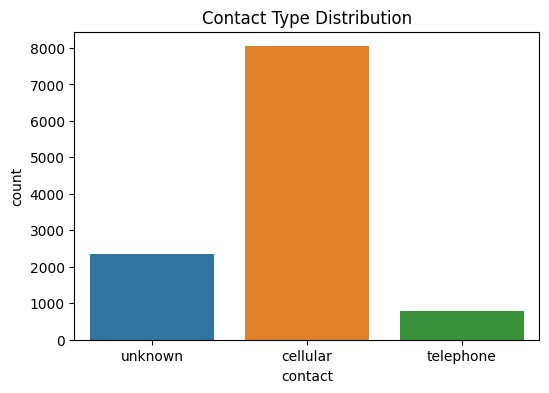

In [38]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="contact")

plt.title("Contact Type Distribution")

plt.show()

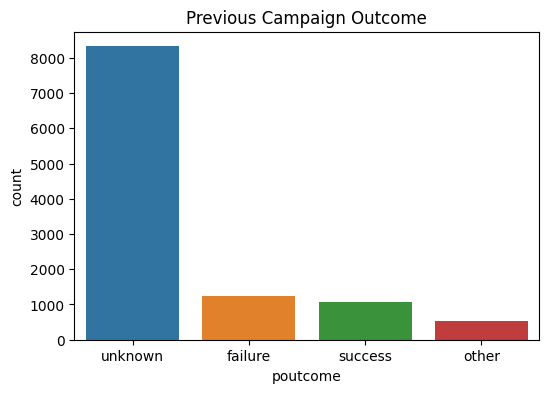

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="poutcome",
    order=df["poutcome"].value_counts().index
)

plt.title("Previous Campaign Outcome")

plt.show()

### EDA 9: Categerical vs Deposit

Job vs Deposit

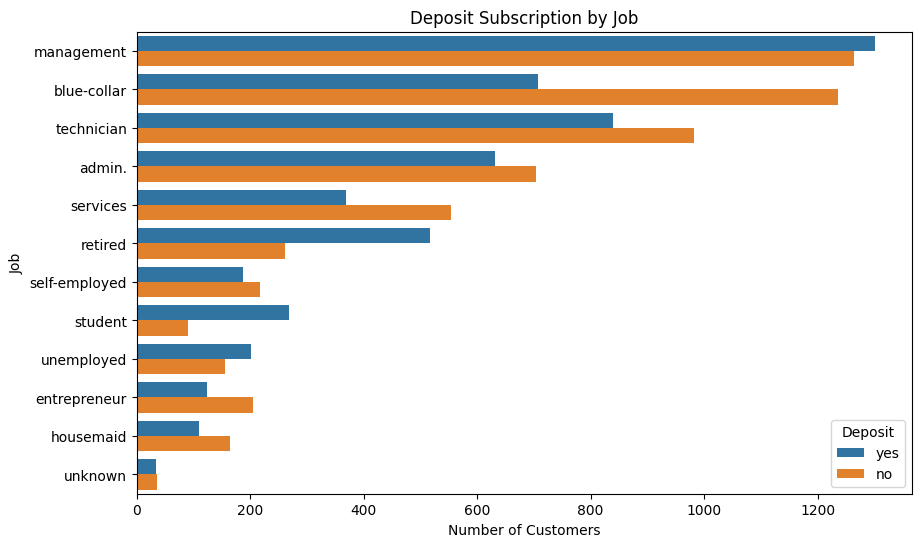

In [41]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="job",
    hue="deposit",
    order=df["job"].value_counts().index
)

plt.title("Deposit Subscription by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")

plt.legend(title="Deposit")

plt.show()

Education vs Deposit

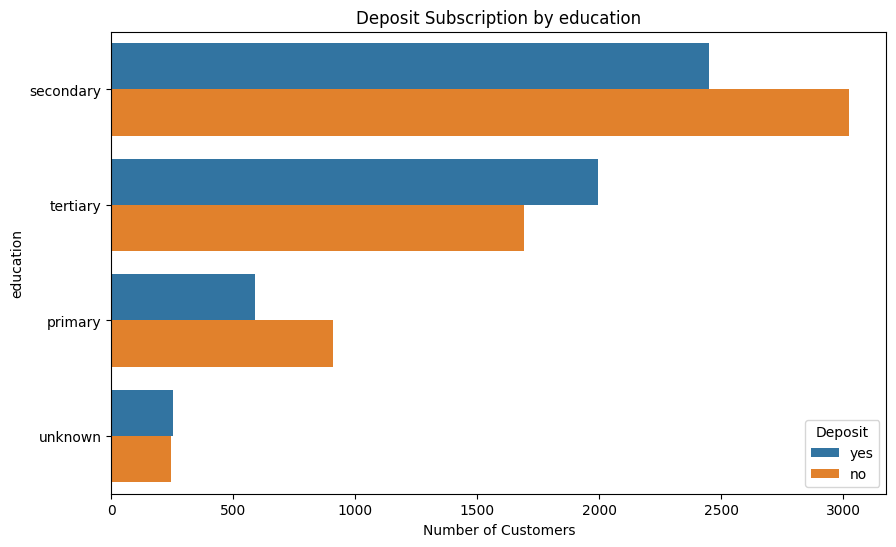

In [42]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="education",
    hue="deposit",
    order=df["education"].value_counts().index
)

plt.title("Deposit Subscription by education")
plt.xlabel("Number of Customers")
plt.ylabel("education")

plt.legend(title="Deposit")

plt.show()

Marital vs Deposit

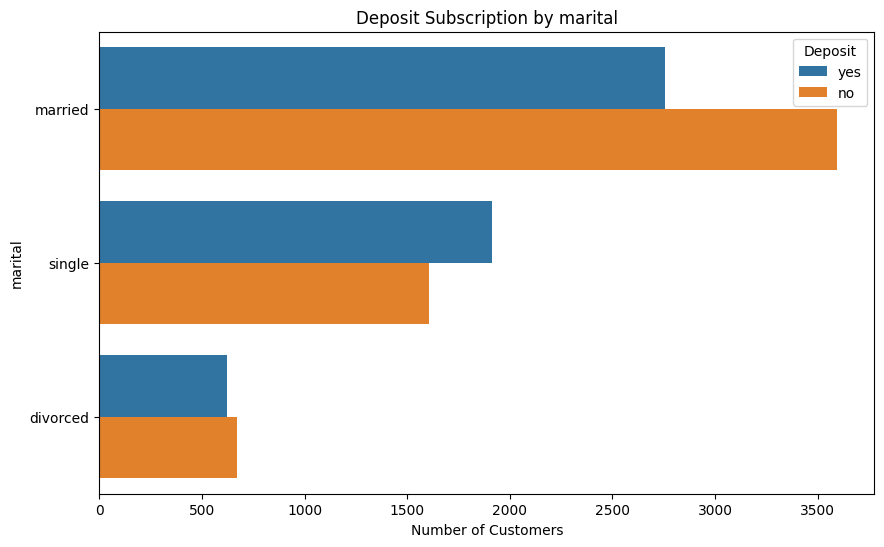

In [43]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="marital",
    hue="deposit",
    order=df["marital"].value_counts().index
)

plt.title("Deposit Subscription by marital")
plt.xlabel("Number of Customers")
plt.ylabel("marital")

plt.legend(title="Deposit")

plt.show()

Housing vs Deposit

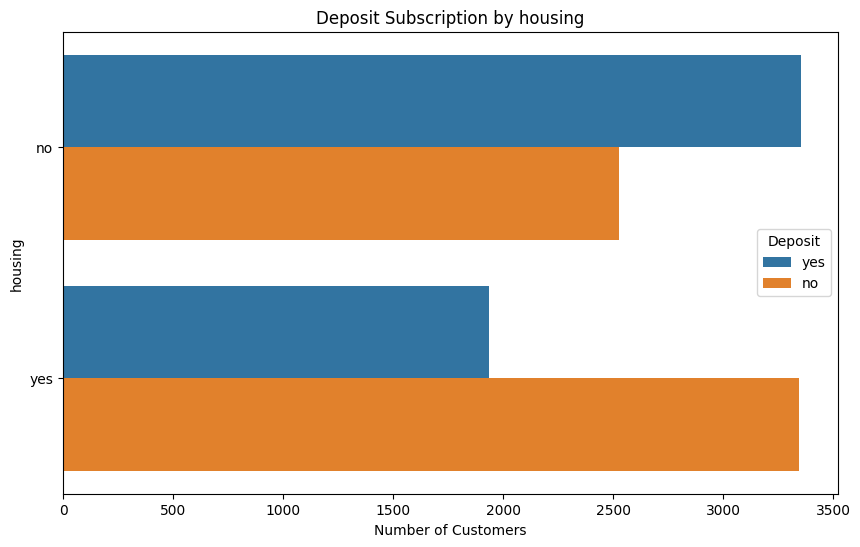

In [44]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="housing",
    hue="deposit",
    order=df["housing"].value_counts().index
)

plt.title("Deposit Subscription by housing")
plt.xlabel("Number of Customers")
plt.ylabel("housing")

plt.legend(title="Deposit")

plt.show()

Loan vs Deposit

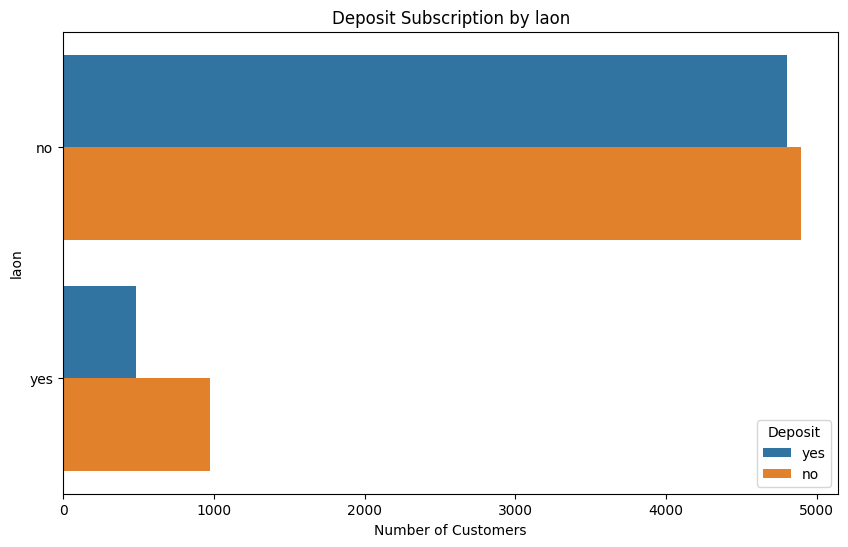

In [45]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="loan",
    hue="deposit",
    order=df["loan"].value_counts().index
)

plt.title("Deposit Subscription by laon")
plt.xlabel("Number of Customers")
plt.ylabel("laon")

plt.legend(title="Deposit")

plt.show()

Contact vs Deposit

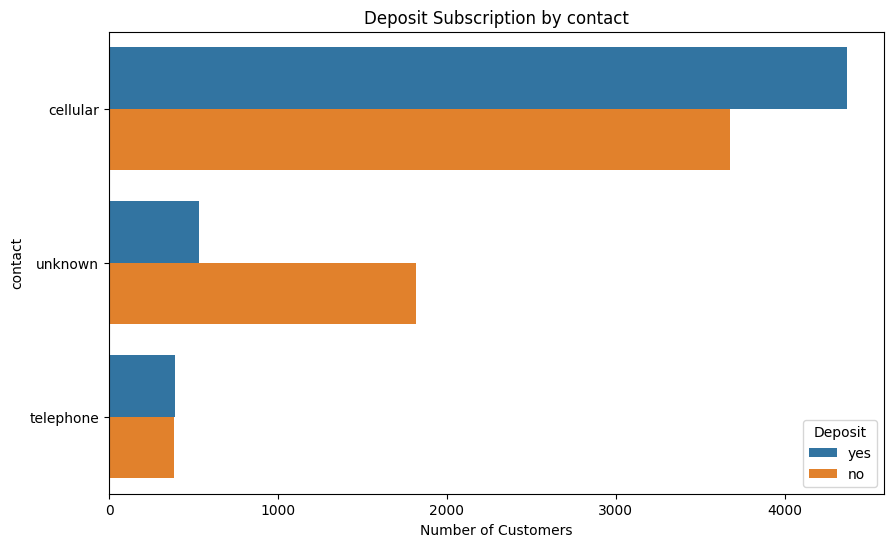

In [46]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="contact",
    hue="deposit",
    order=df["contact"].value_counts().index
)

plt.title("Deposit Subscription by contact")
plt.xlabel("Number of Customers")
plt.ylabel("contact")

plt.legend(title="Deposit")

plt.show()

Month vs Deposit

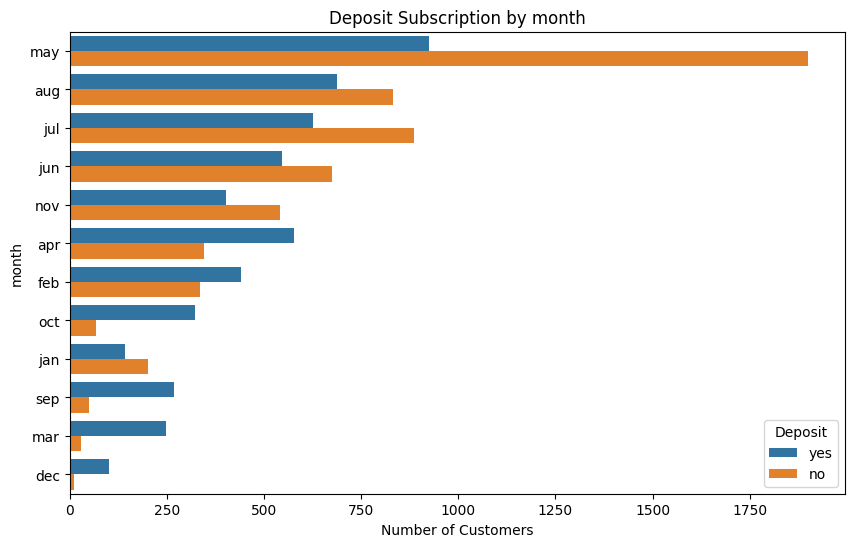

In [47]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="month",
    hue="deposit",
    order=df["month"].value_counts().index
)

plt.title("Deposit Subscription by month")
plt.xlabel("Number of Customers")
plt.ylabel("month")

plt.legend(title="Deposit")

plt.show()

### EDA 10: Numerical Features vs Deposit

Age vs Deposit

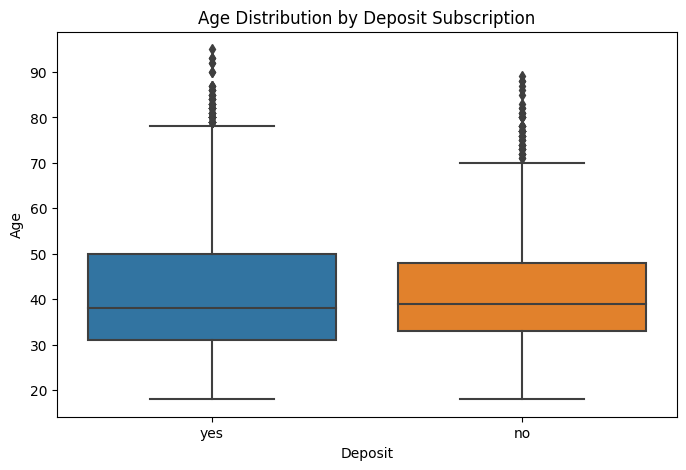

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="deposit",
    y="age"
)

plt.title("Age Distribution by Deposit Subscription")
plt.xlabel("Deposit")
plt.ylabel("Age")

plt.show()

Balance vs Deposit

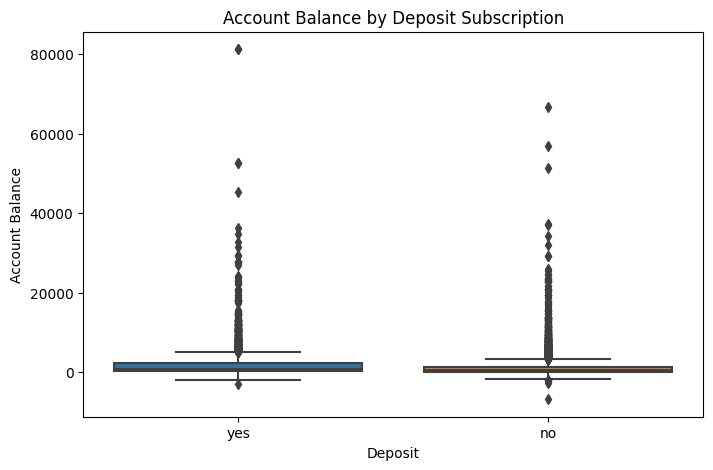

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="deposit",
    y="balance"
)

plt.title("Account Balance by Deposit Subscription")
plt.xlabel("Deposit")
plt.ylabel("Account Balance")

plt.show()

Duration vs Deposit

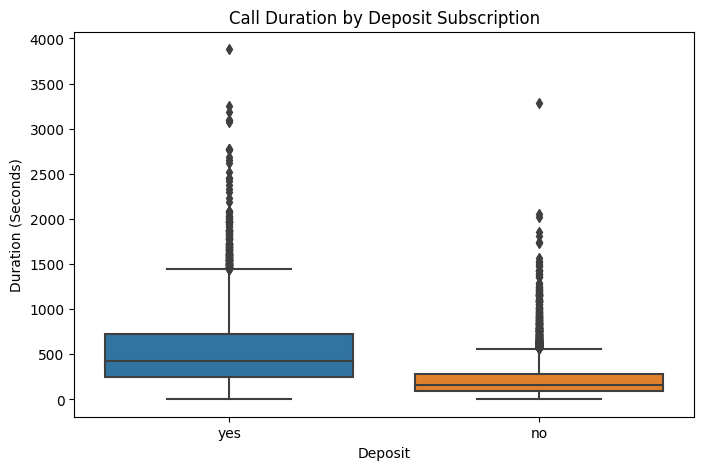

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="deposit",
    y="duration"
)

plt.title("Call Duration by Deposit Subscription")
plt.xlabel("Deposit")
plt.ylabel("Duration (Seconds)")

plt.show()

Campaign vs Deposit

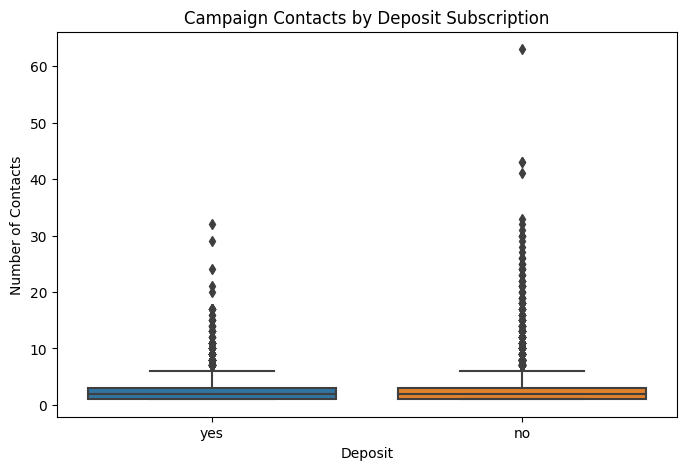

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="deposit",
    y="campaign"
)

plt.title("Campaign Contacts by Deposit Subscription")
plt.xlabel("Deposit")
plt.ylabel("Number of Contacts")

plt.show()

### Correlation Heatmap

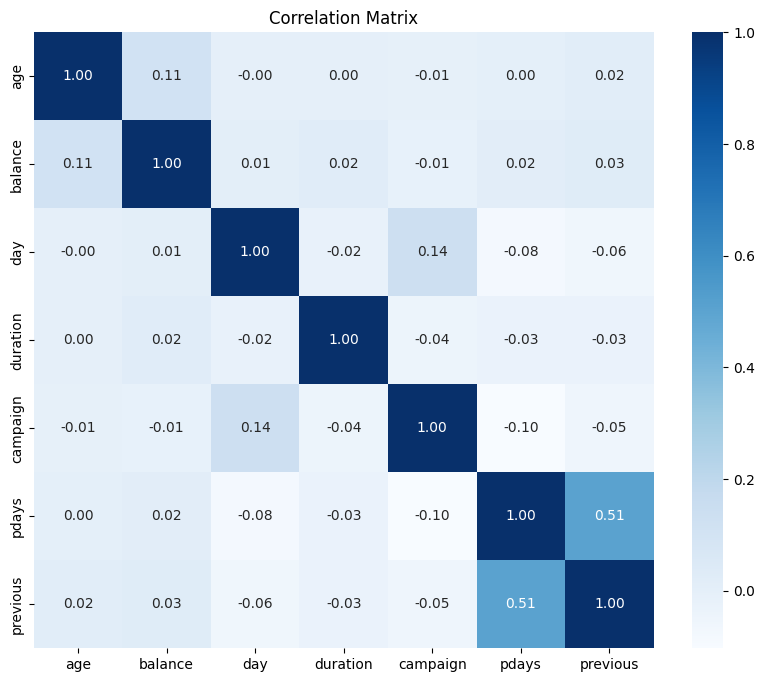

In [52]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

___________________________________________________________

### Data Preprocessing

Encode Target Variable

In [ ]:
df["deposit"] = df["deposit"].map({
    "yes": 1,
    "no": 0
})

df["deposit"].head()

0    1
1    1
2    1
3    1
4    1
Name: deposit, dtype: int64

Job

In [55]:
pd.get_dummies(df["job"])

,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
0,True,False,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
11157,False,True,False,False,False,False,False,False,False,False,False,False
11158,False,False,False,False,False,False,False,True,False,False,False,False
11159,False,False,False,False,False,False,False,False,False,True,False,False
11160,False,False,False,False,False,False,False,False,False,True,False,False


In [56]:
categorical_cols = df.select_dtypes(include="object").columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  11162 non-null  int64
 1   balance              11162 non-null  int64
 2   day                  11162 non-null  int64
 3   duration             11162 non-null  int64
 4   campaign             11162 non-null  int64
 5   pdays                11162 non-null  int64
 6   previous             11162 non-null  int64
 7   deposit              11162 non-null  int64
 8   job_blue-collar      11162 non-null  int32
 9   job_entrepreneur     11162 non-null  int32
 10  job_housemaid        11162 non-null  int32
 11  job_management       11162 non-null  int32
 12  job_retired          11162 non-null  int32
 13  job_self-employed    11162 non-null  int32
 14  job_services         11162 non-null  int32
 15  job_student          11162 non-null  int32
 16  job_technician       1

In [58]:
df.shape

(11162, 43)

### Split Features and Target

In [59]:
X = df.drop("deposit", axis=1)

y = df["deposit"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (11162, 42)
y Shape: (11162,)


### Train-Test Split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8929, 42)
X_test : (2233, 42)
y_train: (8929,)
y_test : (2233,)


Feature Scaling

In [62]:
from sklearn.preprocessing import StandardScaler

In [63]:
scaler = StandardScaler()

In [64]:
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
# for test data, we only transform it using the already fitted scaler
X_test_scaled = scaler.transform(X_test)

In [66]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(8929, 42)
(2233, 42)


## Machine learning

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [68]:
log_model = LogisticRegression(random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)

rf_model = RandomForestClassifier(random_state=42)

svm_model = SVC(random_state=42)

In [69]:
log_model.fit(X_train_scaled, y_train)

dt_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)

svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [70]:
log_pred = log_model.predict(X_test_scaled)

dt_pred = dt_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

svm_pred = svm_model.predict(X_test_scaled)

Evaluation Metrics


In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [72]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine"
    ],

    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ],

    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred)
    ],

    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred)
    ],

    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.841021,0.814488,0.864105,0.838563
3,Support Vector Machine,0.836543,0.824399,0.835989,0.830154
0,Logistic Regression,0.808330,0.811100,0.780694,0.795606
1,Decision Tree,0.789521,0.783476,0.773196,0.778302


Confusion Martix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


Logistic Regression

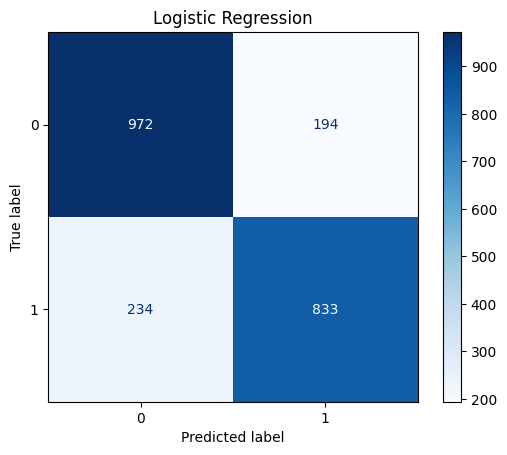

In [74]:
cm = confusion_matrix(y_test, log_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Logistic Regression")
plt.show()


Decision Tree

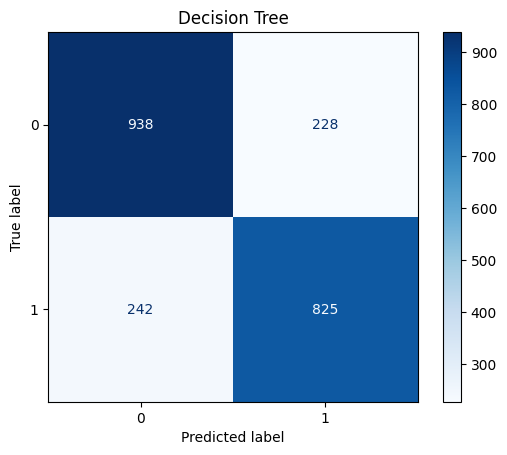

In [76]:
cm = confusion_matrix(y_test, dt_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Decision Tree")
plt.show()

Random Forest

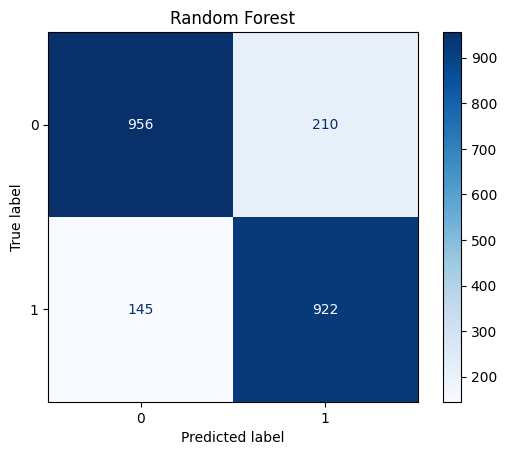

In [77]:
cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Random Forest")
plt.show()

Support Vector Machine

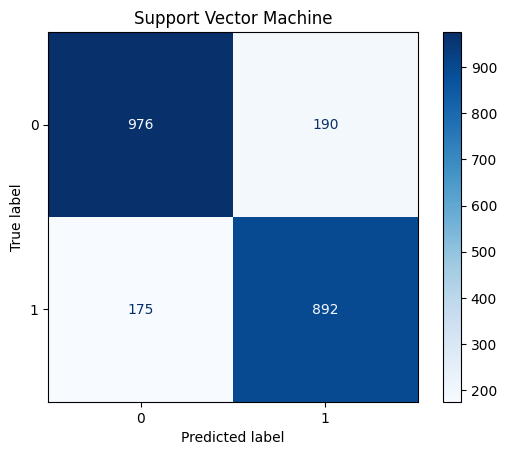

In [75]:
cm = confusion_matrix(y_test, svm_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Support Vector Machine")
plt.show()

#### Classification Report

In [78]:
from sklearn.metrics import classification_report

In [79]:
print("Logistic Regression")
print(classification_report(y_test, log_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1166
           1       0.81      0.78      0.80      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



In [80]:
print("Decision Tree")
print(classification_report(y_test, dt_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.79      0.80      0.80      1166
           1       0.78      0.77      0.78      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



In [81]:
print("Random Forest")
print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1166
           1       0.81      0.86      0.84      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233



In [82]:
print("Support Vector Machine")
print(classification_report(y_test, svm_pred))

Support Vector Machine
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1166
           1       0.82      0.84      0.83      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233

